In [34]:
import pandas as pd 
prices=pd.read_csv("sample_prices.csv")
returns=prices.pct_change()
returns

,BLUE,ORANGE
0,NaN,NaN
1,0.023621,0.039662
2,-0.021807,-0.033638
3,-0.031763,0.082232
4,0.034477,0.044544
5,0.037786,-0.026381
6,-0.011452,-0.049187
7,0.032676,0.117008
8,-0.012581,0.067353
9,0.029581,0.078249


In [35]:
returns=returns.dropna()
returns


,BLUE,ORANGE
1,0.023621,0.039662
2,-0.021807,-0.033638
3,-0.031763,0.082232
4,0.034477,0.044544
5,0.037786,-0.026381
6,-0.011452,-0.049187
7,0.032676,0.117008
8,-0.012581,0.067353
9,0.029581,0.078249
10,0.006151,-0.168261


In [36]:
returns.std()

BLUE      0.023977
ORANGE    0.079601
dtype: float64

In [37]:
deviation=returns - returns.mean()
squared_deviations=deviation**2
variance=squared_deviations.mean()
import numpy as np
volatility= np.sqrt(variance)
volatility

BLUE      0.022957
ORANGE    0.076212
dtype: float64

In [38]:
returns

,BLUE,ORANGE
1,0.023621,0.039662
2,-0.021807,-0.033638
3,-0.031763,0.082232
4,0.034477,0.044544
5,0.037786,-0.026381
6,-0.011452,-0.049187
7,0.032676,0.117008
8,-0.012581,0.067353
9,0.029581,0.078249
10,0.006151,-0.168261


In [39]:
returns.shape

(12, 2)

In [40]:
number_of_obs=returns.shape[0]
variance=squared_deviations.sum()/(number_of_obs-1)
volatility=variance**0.5
volatility

BLUE      0.023977
ORANGE    0.079601
dtype: float64

In [41]:
returns.std()

BLUE      0.023977
ORANGE    0.079601
dtype: float64

In [42]:
returns.std()*np.sqrt(12)

BLUE      0.083060
ORANGE    0.275747
dtype: float64

In [43]:
returns=pd.read_csv("Portfolios_Formed_on_ME_monthly_EW.csv",header=0,index_col=0,parse_dates=True,na_values=-99.99)


/tmp/ipykernel_5327/715058591.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  returns=pd.read_csv("Portfolios_Formed_on_ME_monthly_EW.csv",header=0,index_col=0,parse_dates=True,na_values=-99.99)


In [44]:
returns.head()

,<= 0,Lo 30,Med 40,Hi 30,Lo 20,Qnt 2,Qnt 3,Qnt 4,Hi 20,Lo 10,Dec 2,Dec 3,Dec 4,Dec 5,Dec 6,Dec 7,Dec 8,Dec 9,Hi 10
192607,NaN,-0.43,1.52,2.68,-0.57,0.59,1.60,1.47,3.33,-1.45,0.29,-0.15,1.33,1.24,1.98,1.55,1.38,3.38,3.29
192608,NaN,3.90,3.04,2.09,3.84,3.59,3.71,1.61,2.33,5.12,2.59,4.03,3.15,2.72,4.72,1.60,1.63,0.98,3.70
192609,NaN,-1.08,-0.54,0.16,-0.48,-1.40,0.00,-0.50,-0.09,0.93,-1.87,-2.27,-0.53,0.07,-0.07,-1.64,0.64,-0.86,0.67
192610,NaN,-3.32,-3.52,-3.06,-3.29,-4.10,-2.89,-3.36,-2.95,-4.84,-1.77,-3.36,-4.83,-2.98,-2.80,-3.45,-3.27,-3.47,-2.43
192611,NaN,-0.46,3.82,3.09,-0.55,2.18,3.41,3.39,3.16,-0.78,-0.32,-0.29,4.65,3.24,3.57,3.82,2.95,3.61,2.70


In [45]:
columns=['Lo 10','Hi 10']
returns=returns[columns]
returns.head()

,Lo 10,Hi 10
192607,-1.45,3.29
192608,5.12,3.70
192609,0.93,0.67
192610,-4.84,-2.43
192611,-0.78,2.70


In [46]:
returns= returns/100

In [47]:
returns.head()

,Lo 10,Hi 10
192607,-0.0145,0.0329
192608,0.0512,0.0370
192609,0.0093,0.0067
192610,-0.0484,-0.0243
192611,-0.0078,0.0270


In [48]:
returns.columns=["SmallCap","LargeCap"]

In [49]:
returns.head()

,SmallCap,LargeCap
192607,-0.0145,0.0329
192608,0.0512,0.0370
192609,0.0093,0.0067
192610,-0.0484,-0.0243
192611,-0.0078,0.0270


<Axes: >

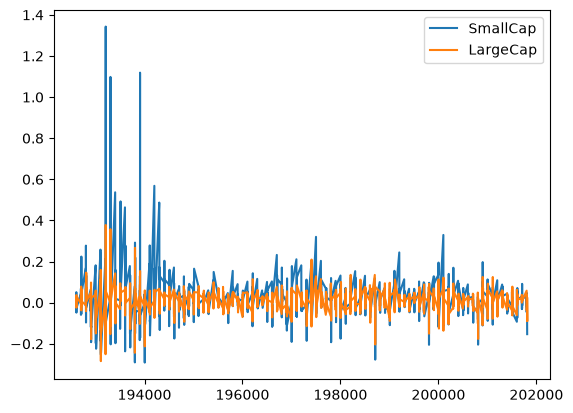

In [50]:
returns.plot()

In [51]:
returns.std()

SmallCap    0.106288
LargeCap    0.053900
dtype: float64

In [53]:
annualise=returns.std()*np.sqrt(12)
annualise

SmallCap    0.368193
LargeCap    0.186716
dtype: float64

In [56]:
n_months=returns.shape[0]
return_per_month=(returns+1).prod()**(1/n_months)-1

In [57]:
return_per_month

SmallCap    0.012986
LargeCap    0.007423
dtype: float64

In [58]:
annualise_return=(return_per_month+1)**12 -1
annualise_return

SmallCap    0.167463
LargeCap    0.092810
dtype: float64

In [59]:
annualise_return=(returns+1).prod()**(12/n_months)-1

In [61]:
annualise_return

SmallCap    0.167463
LargeCap    0.092810
dtype: float64

In [63]:
annualise_return/annualise

SmallCap    0.454825
LargeCap    0.497063
dtype: float64

In [66]:
riskfree_rate=0.03
excess_return=annualise_return-riskfree_rate
sharpe_ratio=excess_return/annualise
sharpe_ratio

SmallCap    0.373346
LargeCap    0.336392
dtype: float64

In [67]:
returns

,SmallCap,LargeCap
192607,-0.0145,0.0329
192608,0.0512,0.0370
192609,0.0093,0.0067
192610,-0.0484,-0.0243
192611,-0.0078,0.0270
...,...,...
201808,0.0241,0.0234
201809,-0.0168,0.0087
201810,-0.1002,-0.0657
201811,-0.0365,0.0253


In [68]:
data=pd.read_csv("Portfolios_Formed_on_ME_monthly_EW.csv",
                 header=0,index_col=0,parse_dates=True,na_values=-99.99)

/tmp/ipykernel_5327/308125989.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data=pd.read_csv("Portfolios_Formed_on_ME_monthly_EW.csv",


In [103]:
data

,<= 0,Lo 30,Med 40,Hi 30,Lo 20,Qnt 2,Qnt 3,Qnt 4,Hi 20,Lo 10,Dec 2,Dec 3,Dec 4,Dec 5,Dec 6,Dec 7,Dec 8,Dec 9,Hi 10
192607,NaN,-0.43,1.52,2.68,-0.57,0.59,1.60,1.47,3.33,-1.45,0.29,-0.15,1.33,1.24,1.98,1.55,1.38,3.38,3.29
192608,NaN,3.90,3.04,2.09,3.84,3.59,3.71,1.61,2.33,5.12,2.59,4.03,3.15,2.72,4.72,1.60,1.63,0.98,3.70
192609,NaN,-1.08,-0.54,0.16,-0.48,-1.40,0.00,-0.50,-0.09,0.93,-1.87,-2.27,-0.53,0.07,-0.07,-1.64,0.64,-0.86,0.67
192610,NaN,-3.32,-3.52,-3.06,-3.29,-4.10,-2.89,-3.36,-2.95,-4.84,-1.77,-3.36,-4.83,-2.98,-2.80,-3.45,-3.27,-3.47,-2.43
192611,NaN,-0.46,3.82,3.09,-0.55,2.18,3.41,3.39,3.16,-0.78,-0.32,-0.29,4.65,3.24,3.57,3.82,2.95,3.61,2.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201808,NaN,3.47,4.04,2.87,3.09,5.05,3.90,3.54,2.49,2.41,5.07,5.30,4.70,3.02,5.01,3.50,3.58,2.65,2.34
201809,NaN,-2.24,-1.85,0.08,-2.04,-2.38,-2.48,-0.74,0.19,-1.68,-3.08,-3.22,-1.23,-2.65,-2.27,-1.31,-0.12,-0.51,0.87
201810,NaN,-10.76,-10.88,-7.63,-10.52,-11.74,-10.55,-9.45,-7.41,-10.02,-11.98,-11.89,-11.52,-11.58,-9.23,-10.74,-8.04,-8.28,-6.57
201811,NaN,-2.08,2.18,2.19,-2.78,1.69,1.46,2.62,2.49,-3.65,-0.23,1.23,2.30,1.74,1.11,3.54,1.63,2.45,2.53


In [84]:
columns=["Lo 20","Hi 20"]
datas=data[columns]
datas.head()
datas=datas/100

In [85]:
datas.std()

Lo 20    0.097197
Hi 20    0.056325
dtype: float64

In [86]:
annualise=datas.std()*np.sqrt(12)
annualise

Lo 20    0.336701
Hi 20    0.195116
dtype: float64

<Axes: >

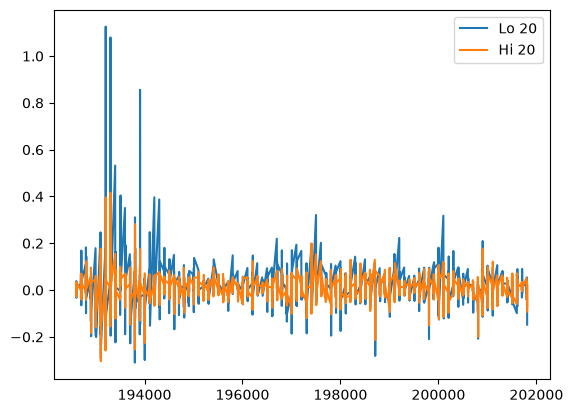

In [87]:
datas.plot()

In [88]:
datas.mean()

Lo 20    0.015904
Hi 20    0.009434
dtype: float64

In [104]:
no_of_obs=datas.shape[0]
print(no_of_obs)
volatility=datas-datas.mean()
sq=volatility**2
vol=sq.sum()/(no_of_obs-1)
vol=vol**0.5
vol

1110


Lo 20    0.097197
Hi 20    0.056325
dtype: float64

In [93]:
datas.std()

Lo 20    0.097197
Hi 20    0.056325
dtype: float64

In [106]:
no_of_month=datas.shape[0]
returns=(datas+1).prod()**(12/no_of_month) -1
returns

Lo 20    0.151977
Hi 20    0.098490
dtype: float64

In [107]:
risk_free_return=0.03
total=returns-risk_free_return
sharpe=total/annualise
sharpe

Lo 20    0.362271
Hi 20    0.351023
dtype: float64